# Relation Extraction for Arabic — the Rabt RE system, end to end

This notebook walks you through — and lets you run — the Subtask 2 (Relation
Extraction) system from the paper *"Rabt at KnowledgeGraphEval 2026"* (Team
Rabt, ArabicNLP 2026): typed-marker relation classification over AraBERTv02
with soft type-constraint decoding and a grouped fold ensemble. It is the
sequel to notebook 1 (`01-adaptner-nested-ner.ipynb`), which found the
entities — but it stands alone: here the entity mentions are *given*, and the
job is to decide how each pair of them is related.

**How to use this notebook.** Runtime → Change runtime type → **T4 GPU**, then
Runtime → **Run all**. The default is the quick path: a synthetic Arabic toy
dataset is built in §3 and short training runs demonstrate every mechanic.
Set the `KGEVAL_FULL=1` env var (or flip `FULL_REPLICATION` in the config
cell) for paper-exact configs — note that flag alone still runs them on the
*toy* data; an actual replication needs the §3 files as well. Toy numbers show
*mechanics, not quality* — the paper's real numbers are in §10, together with
the recipe that reproduces them on the real data.

## 1. What we're building

Subtask 2 hands you an Arabic sentence plus two marked mentions — a **subject**
and an **object** — and asks for exactly one of **40 relation types**
(`Personal.birth_place`, `PartOf.subsidiary`, …). It is *forced choice*: the
test set contains no negative pairs, so abstaining is impossible and micro-F1
= precision = recall = accuracy. This is the second half of the knowledge
graph: notebook 1's NER produces *nodes* (typed entity mentions); relation
extraction adds the *edges* — NER output alone is not a graph yet. The data
is **WojoodRelations**: 17,381 labeled training records (46.6% of them
`no_relation` negative pairs) and a blind test of 4,386 positive pairs.

## 2. Setup

First a runtime sanity check. Training the real system wants a GPU (Colab:
Runtime → Change runtime type → T4, the paper's own compute tier); the toy
path in this notebook also works on CPU, just slower.

In [ ]:
try:
    import torch
    print(f"torch {torch.__version__} — CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("no GPU — the quick toy path still runs; full replication wants a T4")
except ImportError:
    print("torch is not installed yet — the next cell installs it")

torch 2.11.0+cu128 — CUDA available: True
GPU: Tesla T4


Colab ships torch and transformers preinstalled; on a bare environment this
cell installs them. Everything else the notebook needs is the project's own
`kgeval` package, vendored in the cells right after.

In [ ]:
try:
    import torch, transformers
    print(f"torch {torch.__version__} / transformers {transformers.__version__} (already available)")
except ImportError:
    %pip install -q torch transformers
    import torch, transformers
    print(f"installed torch {torch.__version__} / transformers {transformers.__version__}")

torch 2.11.0+cu128 / transformers 5.13.1 (already available)


The paper's system lives in the repo's `kgeval` Python package. To keep this
notebook self-contained, the next cells write the package's modules into the
runtime **verbatim** (`%%writefile kgeval/<module>.py`) — the exact code the
paper reports on, nothing re-implemented for teaching. Each module is short
and documented; skim them if you like, the sections below exercise them one
by one.

In [ ]:
import os
os.makedirs("kgeval", exist_ok=True)
print("writing kgeval package into", os.getcwd())

writing kgeval package into /content


In [ ]:
%%writefile kgeval/__init__.py
"""Team Rabt tooling for KnowledgeGraphEval 2026 (AdaptNER + Relation Extraction).

Format contracts implemented here are specified in
docs/knowledgegrapheval_2026_solution_design.md §1 and were verified against the
local task data and the Codabench page captures.
"""

__version__ = "0.1.0"


Overwriting kgeval/__init__.py


In [ ]:
%%writefile kgeval/columns.py
"""Canonical AdaptNER column contract.

The Codabench scorer reads the 21 tag columns positionally in this fixed
(alphabetical) order — a wrong order scores silently wrong, so every module
that touches the 22-field format imports the constants from here and nowhere
else.
"""

ENTITY_TYPES: tuple[str, ...] = (
    "CARDINAL",
    "CURR",
    "DATE",
    "EVENT",
    "FAC",
    "GPE",
    "LANGUAGE",
    "LAW",
    "LOC",
    "MONEY",
    "NORP",
    "OCC",
    "ORDINAL",
    "ORG",
    "PERCENT",
    "PERS",
    "PRODUCT",
    "QUANTITY",
    "TIME",
    "UNIT",
    "WEBSITE",
)

NUM_TYPES = len(ENTITY_TYPES)
TYPE_INDEX: dict[str, int] = {t: i for i, t in enumerate(ENTITY_TYPES)}

assert NUM_TYPES == 21
assert list(ENTITY_TYPES) == sorted(ENTITY_TYPES), "contract order is alphabetical"

# The 10 Konooz domains; submissions concatenate domain files in sorted() order.
# Validators derive the actual order from the released test directory listing and
# cross-check it against this fallback.
KONOOZ_DOMAINS: tuple[str, ...] = (
    "Agriculture",
    "Art",
    "Economics",
    "Finance",
    "Health",
    "History",
    "Law",
    "Politics",
    "Science",
    "Sport",
)


def valid_column_tags(type_name: str) -> frozenset[str]:
    """The only strings admissible in the column of `type_name`."""
    return frozenset(("O", f"B-{type_name}", f"I-{type_name}"))


Overwriting kgeval/columns.py


In [ ]:
%%writefile kgeval/spans.py
"""Per-column BIO decoding with IOB repair, and span-set extraction.

Spans are (start, end_exclusive, type) over token positions within one
sentence. An `I-x` with no open span of type x (after O or at sentence start)
starts a new span and is counted as a repair — the standard IOB2 repair, also
applied to model output before submission writing.
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass

from .columns import ENTITY_TYPES, TYPE_INDEX

Span = tuple[int, int, str]


@dataclass
class DecodeResult:
    spans: set[Span]
    n_repairs: int = 0


def decode_bio_column(tags: list[str], type_name: str) -> DecodeResult:
    """Decode one type column of one sentence."""
    spans: set[Span] = set()
    repairs = 0
    start: int | None = None
    for i, tag in enumerate(tags):
        if tag == "O":
            if start is not None:
                spans.add((start, i, type_name))
                start = None
        elif tag == f"B-{type_name}":
            if start is not None:
                spans.add((start, i, type_name))
            start = i
        elif tag == f"I-{type_name}":
            if start is None:  # orphan I- → repaired to a span start
                start = i
                repairs += 1
        else:
            raise ValueError(f"tag {tag!r} not admissible in column {type_name}")
    if start is not None:
        spans.add((start, len(tags), type_name))
    return DecodeResult(spans=spans, n_repairs=repairs)


def spans_from_rows(tag_rows: list[list[str]]) -> DecodeResult:
    """All typed spans of one sentence given per-token 21-tag rows."""
    all_spans: set[Span] = set()
    repairs = 0
    for ci, type_name in enumerate(ENTITY_TYPES):
        column = [row[ci] for row in tag_rows]
        res = decode_bio_column(column, type_name)
        all_spans |= res.spans
        repairs += res.n_repairs
    return DecodeResult(spans=all_spans, n_repairs=repairs)


def encode_spans_to_rows(spans: set[Span] | list[Span], n_tokens: int) -> list[list[str]]:
    """Per-token 21-tag rows from a span set (inverse of spans_from_rows).

    Same-type spans must be non-overlapping — a per-type BIO column cannot
    encode same-type overlap; resolve conflicts first (see union_tag_rows).
    Adjacent same-type spans round-trip: the second one starts with B-.
    """
    rows = [["O"] * len(ENTITY_TYPES) for _ in range(n_tokens)]
    by_type: dict[str, list[Span]] = {}
    for span in spans:
        start, end, typ = span
        if not (0 <= start < end <= n_tokens):
            raise ValueError(f"span {span} out of bounds for {n_tokens} tokens")
        by_type.setdefault(typ, []).append(span)
    for typ, tspans in by_type.items():
        ci = TYPE_INDEX[typ]
        prev_end = -1
        for start, end, _ in sorted(tspans):
            if start < prev_end:
                raise ValueError(f"overlapping {typ} spans cannot share a BIO column")
            rows[start][ci] = f"B-{typ}"
            for i in range(start + 1, end):
                rows[i][ci] = f"I-{typ}"
            prev_end = end
    return rows


@dataclass
class EnsembleResult:
    rows: list[list[str]]
    spans: set[Span]
    n_dropped: int  # candidates discarded by same-type overlap resolution


def union_tag_rows(
    rows_per_model: list[list[list[str]]], min_votes: int = 1
) -> EnsembleResult:
    """Span-level vote ensemble of one sentence tagged by several models.

    Decodes each model's spans (IOB repair applied), keeps spans reaching
    min_votes (1 = pure union — the recall lever), then resolves same-type
    overlaps greedily by (votes desc, length desc, start asc) since a BIO
    column cannot encode same-type overlap. Deterministic given input order.
    """
    if not rows_per_model:
        raise ValueError("need at least one model's rows")
    n_tokens = len(rows_per_model[0])
    if any(len(rows) != n_tokens for rows in rows_per_model):
        raise ValueError("models disagree on sentence length")
    votes: Counter[Span] = Counter()
    for rows in rows_per_model:
        votes.update(spans_from_rows(rows).spans)
    candidates = sorted(
        (s for s, v in votes.items() if v >= min_votes),
        key=lambda s: (-votes[s], -(s[1] - s[0]), s[0], s[2]),
    )
    accepted: list[Span] = []
    occupied: dict[str, list[tuple[int, int]]] = {}
    dropped = 0
    for start, end, typ in candidates:
        if any(start < e and b < end for b, e in occupied.get(typ, [])):
            dropped += 1
            continue
        accepted.append((start, end, typ))
        occupied.setdefault(typ, []).append((start, end))
    return EnsembleResult(
        rows=encode_spans_to_rows(accepted, n_tokens),
        spans=set(accepted),
        n_dropped=dropped,
    )


Overwriting kgeval/spans.py


In [ ]:
%%writefile kgeval/wojood.py
"""Readers for the Wojood nested release (training side of AdaptNER).

`train/val/test.txt` are token-per-line with a variable-length space-separated
tag list (1–5 tags), outer entity listed first, e.g. `ملز I-MONEY B-CURR`.
Blank lines separate sentences. The `.csv` twin adds `global_sentence_id` and
`Sub_corpus` — the join keys used by the RE task and by leave-subcorpus-out
model selection.
"""

from __future__ import annotations

import csv
import re
from dataclasses import dataclass, field
from pathlib import Path

from .columns import ENTITY_TYPES

# token, then 1..n tags; tags are O or [BI]-TYPE with TYPE from the 21-type set.
_TAG_RE = re.compile(r"^(O|[BI]-([A-Z]+))$")

# (token, [tags outer→inner]) per token.
Token = tuple[str, list[str]]
Sentence = list[Token]


@dataclass
class NestedCorpus:
    sentences: list[Sentence]
    anomalies: list[str] = field(default_factory=list)

    @property
    def n_tokens(self) -> int:
        return sum(len(s) for s in self.sentences)


def read_nested_txt(path: str | Path, strict: bool = True) -> NestedCorpus:
    """Parse a Wojood nested .txt file.

    strict=True raises on any malformed tag line; strict=False records the
    anomaly and keeps the line (unknown tags are preserved verbatim so the
    caller can inspect them).
    """
    sentences: list[Sentence] = []
    current: Sentence = []
    anomalies: list[str] = []

    with open(path, encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.rstrip("\r\n")
            if not line.strip():
                if current:
                    sentences.append(current)
                    current = []
                continue
            parts = line.split()
            token, tags = parts[0], parts[1:]
            if not tags:
                anomalies.append(f"{path}:{lineno}: token line without tags: {line!r}")
                tags = ["O"]
            for tag in tags:
                m = _TAG_RE.match(tag)
                if not m or (m.group(2) is not None and m.group(2) not in ENTITY_TYPES):
                    anomalies.append(f"{path}:{lineno}: unknown tag {tag!r}")
            if "O" in tags and len(tags) > 1:
                anomalies.append(f"{path}:{lineno}: O combined with entity tags: {tags}")
            current.append((token, tags))
    if current:
        sentences.append(current)

    if strict and anomalies:
        preview = "\n".join(anomalies[:5])
        raise ValueError(
            f"{len(anomalies)} malformed tag lines in {path}; first cases:\n{preview}"
        )
    return NestedCorpus(sentences=sentences, anomalies=anomalies)


def read_sentence_subcorpus(csv_path: str | Path) -> dict[str, str]:
    """Map global_sentence_id → Sub_corpus from a Wojood .csv (file order kept)."""
    mapping: dict[str, str] = {}
    with open(csv_path, encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            gsid = row["global_sentence_id"]
            if gsid not in mapping:
                mapping[gsid] = row["Sub_corpus"]
    return mapping


def read_csv_sentences(csv_path: str | Path) -> dict[str, list[str]]:
    """Map global_sentence_id → token list (for the RE sentence_id join)."""
    sentences: dict[str, list[str]] = {}
    with open(csv_path, encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            sentences.setdefault(row["global_sentence_id"], []).append(row["token"])
    return sentences


Overwriting kgeval/wojood.py


In [ ]:
%%writefile kgeval/convert.py
"""Convert Wojood variable-width nested tags → the fixed 21-column format.

Rule (design doc §1.1): each type column receives that type's B-/I- tag; on a
same-type collision (an inner and an outer entity of the same type on one
token) the OUTER (first-listed) tag wins. Same-type nesting is unrepresentable
in the official format; Wojood contains only ~576 such nested pairs corpus-wide,
so the loss is negligible — but it is counted and reported, never silent.
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

from .columns import ENTITY_TYPES, TYPE_INDEX
from .wojood import NestedCorpus, Sentence, read_nested_txt


@dataclass
class ConvertStats:
    n_sentences: int = 0
    n_tokens: int = 0
    n_multi_tag_tokens: int = 0
    n_same_type_collisions: int = 0
    collisions_by_type: Counter = field(default_factory=Counter)
    nesting_pairs: Counter = field(default_factory=Counter)  # (outer, inner) token counts


def nested_tags_to_columns(tags: list[str], stats: ConvertStats | None = None) -> list[str]:
    """One token's outer→inner tag list → its 21 column tags."""
    columns = ["O"] * len(ENTITY_TYPES)
    seen_types: list[str] = []
    for tag in tags:
        if tag == "O":
            continue
        typ = tag.split("-", 1)[1]
        ci = TYPE_INDEX[typ]
        if columns[ci] == "O":
            columns[ci] = tag
        elif stats is not None:
            stats.n_same_type_collisions += 1
            stats.collisions_by_type[typ] += 1
        if stats is not None:
            for outer in seen_types:
                stats.nesting_pairs[(outer, typ)] += 1
        seen_types.append(typ)
    return columns


def sentence_to_rows(sentence: Sentence, stats: ConvertStats | None = None) -> list[list[str]]:
    """One nested sentence → rows of [token, tag×21]."""
    rows = []
    for token, tags in sentence:
        if stats is not None:
            stats.n_tokens += 1
            if sum(1 for t in tags if t != "O") > 1:
                stats.n_multi_tag_tokens += 1
        rows.append([token] + nested_tags_to_columns(tags, stats))
    if stats is not None:
        stats.n_sentences += 1
    return rows


def convert_corpus(corpus: NestedCorpus) -> tuple[list[list[list[str]]], ConvertStats]:
    stats = ConvertStats()
    docs = [sentence_to_rows(s, stats) for s in corpus.sentences]
    return docs, stats


def convert_file(in_path: str | Path, out_path: str | Path, eol: str = "\n") -> ConvertStats:
    """Wojood nested .txt → 22-field column file (for training-side ingestion)."""
    corpus = read_nested_txt(in_path)
    docs, stats = convert_corpus(corpus)
    out = Path(out_path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as f:
        for si, rows in enumerate(docs):
            for row in rows:
                f.write(" ".join(row) + eol)
            if si != len(docs) - 1:
                f.write(eol)  # blank line between sentences
    return stats


Overwriting kgeval/convert.py


In [ ]:
%%writefile kgeval/splits.py
"""Local evaluation splits.

RE: split by `sentence_id`, never by row — ~2.75 triples share a sentence and
row-level splits leak (design doc §1.2). NER: leave-subcorpus-out folds over
Wojood's `Sub_corpus` column as the domain-shift proxy (§3.4).
"""

from __future__ import annotations

import random
from collections import Counter


def grouped_split(
    records: list[dict],
    val_frac: float = 0.125,
    seed: int = 13,
    group_key: str = "sentence_id",
) -> tuple[list[dict], list[dict], dict]:
    """Deterministic grouped split: whole groups go to one side."""
    groups = sorted({r[group_key] for r in records})
    rng = random.Random(seed)
    rng.shuffle(groups)
    by_group = Counter(r[group_key] for r in records)
    target = val_frac * len(records)
    val_groups: set = set()
    picked = 0
    for g in groups:
        if picked >= target:
            break
        val_groups.add(g)
        picked += by_group[g]
    train = [r for r in records if r[group_key] not in val_groups]
    val = [r for r in records if r[group_key] in val_groups]
    info = {
        "seed": seed,
        "group_key": group_key,
        "n_groups": len(groups),
        "n_val_groups": len(val_groups),
        "n_train": len(train),
        "n_val": len(val),
    }
    return train, val, info


def grouped_kfold(
    records: list[dict],
    k: int = 5,
    seed: int = 13,
    group_key: str = "sentence_id",
) -> list[tuple[list[dict], list[dict]]]:
    """Deterministic grouped K-fold: every group lands in exactly one fold's
    val side, folds balanced by record count (greedy smallest-fold assignment
    over the shuffled groups). Returns [(train, val)] per fold."""
    if k < 2:
        raise ValueError("k must be >= 2")
    groups = sorted({r[group_key] for r in records})
    rng = random.Random(seed)
    rng.shuffle(groups)
    by_group = Counter(r[group_key] for r in records)
    fold_of: dict = {}
    fold_sizes = [0] * k
    for g in groups:
        fi = min(range(k), key=lambda i: fold_sizes[i])
        fold_of[g] = fi
        fold_sizes[fi] += by_group[g]
    folds = []
    for fi in range(k):
        train = [r for r in records if fold_of[r[group_key]] != fi]
        val = [r for r in records if fold_of[r[group_key]] == fi]
        folds.append((train, val))
    return folds


def loso_folds(sentence_subcorpus: dict[str, str]) -> dict[str, set[str]]:
    """Sub_corpus name → set of global_sentence_ids (leave-subcorpus-out folds)."""
    folds: dict[str, set[str]] = {}
    for gsid, sub in sentence_subcorpus.items():
        folds.setdefault(sub, set()).add(gsid)
    return folds


Writing kgeval/splits.py


In [ ]:
%%writefile kgeval/re_data.py
"""Loaders and label utilities for the WojoodRelations track."""

from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

REQUIRED_KEYS = {"sentence_id", "sentence", "triple_id", "subject", "object", "relation"}

_NO_RELATION_RE = re.compile(r"^no[_\-]?relation$", re.IGNORECASE)


def load_jsonl(path: str | Path) -> list[dict]:
    records: list[dict] = []
    with open(path, encoding="utf-8") as f:
        for lineno, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            missing = REQUIRED_KEYS - rec.keys()
            if missing:
                raise ValueError(f"{path}:{lineno}: missing keys {missing}")
            records.append(rec)
    return records


def label_counts(records: list[dict]) -> Counter:
    """Counts of non-empty relation strings, verbatim."""
    return Counter(r["relation"] for r in records if r["relation"])


def detect_no_relation(labels: set[str] | Counter) -> str | None:
    """The corpus's exact negative-class string (e.g. 'no_relation'), if present."""
    for label in labels:
        if _NO_RELATION_RE.match(label):
            return label
    return None


def positive_labels(records: list[dict]) -> list[str]:
    counts = label_counts(records)
    neg = detect_no_relation(counts)
    return sorted(l for l in counts if l != neg)


Writing kgeval/re_data.py


In [ ]:
%%writefile kgeval/re_typing.py
"""Entity typing for RE typed markers (design §4.2).

Chain per record: sentence_id → Wojood global_sentence_id (nested CSV) →
string-match the subject/object against that sentence's gold entities → type.
Fallbacks: corpus-wide entity→type lexicon, then 'UNK' (markers degrade
gracefully to untyped). Every assignment records its source so join coverage
lands in the experiment ledger, per the design doc: measure, don't assume.
"""

from __future__ import annotations

import csv
from collections import Counter
from pathlib import Path

from .convert import sentence_to_rows
from .spans import spans_from_rows
from .wojood import Sentence

UNK_TYPE = "UNK"


def read_csv_nested(csv_path: str | Path) -> dict[str, Sentence]:
    """global_sentence_id → nested sentence [(token, [tags outer→inner])]."""
    sentences: dict[str, Sentence] = {}
    with open(csv_path, encoding="utf-8", newline="") as f:
        for row in csv.DictReader(f):
            tags = row["tags"].split() or ["O"]
            sentences.setdefault(row["global_sentence_id"], []).append(
                (row["token"], tags)
            )
    return sentences


def entity_types(sentence: Sentence) -> dict[str, Counter]:
    """Entity surface string (space-joined tokens) → Counter of its types."""
    rows = sentence_to_rows(sentence)
    tokens = [r[0] for r in rows]
    out: dict[str, Counter] = {}
    for start, end, typ in spans_from_rows([r[1:] for r in rows]).spans:
        text = " ".join(tokens[start:end])
        out.setdefault(text, Counter())[typ] += 1
    return out


def build_lexicon(sentences: dict[str, Sentence]) -> dict[str, Counter]:
    """Corpus-wide entity string → type counts (fallback for unjoined ids)."""
    lexicon: dict[str, Counter] = {}
    for sentence in sentences.values():
        for text, counts in entity_types(sentence).items():
            lexicon.setdefault(text, Counter()).update(counts)
    return lexicon


def type_mention(
    mention: str,
    sentence_entities: dict[str, Counter] | None,
    lexicon: dict[str, Counter],
) -> tuple[str, str]:
    """→ (type, source) with source ∈ {sentence, lexicon, unk}."""
    if sentence_entities and mention in sentence_entities:
        return sentence_entities[mention].most_common(1)[0][0], "sentence"
    if mention in lexicon:
        return lexicon[mention].most_common(1)[0][0], "lexicon"
    return UNK_TYPE, "unk"


def assign_types(
    records: list[dict],
    gsid_sentences: dict[str, Sentence],
    lexicon: dict[str, Counter],
) -> tuple[list[tuple[str, str]], Counter]:
    """Per record (subject_type, object_type) + Counter of assignment sources."""
    types: list[tuple[str, str]] = []
    stats: Counter = Counter()
    ents_cache: dict[str, dict[str, Counter]] = {}
    for rec in records:
        gsid = str(rec["sentence_id"])
        sentence = gsid_sentences.get(gsid)
        if sentence is not None and gsid not in ents_cache:
            ents_cache[gsid] = entity_types(sentence)
        ents = ents_cache.get(gsid)
        stats["joined" if sentence else "unjoined"] += 1
        s_type, s_src = type_mention(rec["subject"], ents, lexicon)
        o_type, o_src = type_mention(rec["object"], ents, lexicon)
        stats[f"subj_{s_src}"] += 1
        stats[f"obj_{o_src}"] += 1
        types.append((s_type, o_type))
    return types, stats


Writing kgeval/re_typing.py


In [ ]:
%%writefile kgeval/re_markers.py
"""Typed entity markers for RE (design §4.1, variant B — Zhou & Chen punct).

Subject mention wrapped as `@ * type * mention @`, object as `# ^ type ^
mention #`; the classifier reads the encoder states at the two start markers,
so their character offsets in the marked text are returned for char_to_token
lookup.

Occurrence ambiguity (5.9% of triples): the non-overlapping occurrence pair
with minimal character distance wins, ties leftmost. Containment pairs — ~20%
of WojoodRelations has the object embedded in the subject mention (e.g.
located_in(نقابة العاملين في جامعة بيرزيت, بيرزيت)) — get nested insertion:
the inner segment goes inside the outer mention, keeping both markers in
context. Degraded cases never raise (blind test data must always encode);
they are labeled in `fallback` and counted by the caller.
"""

from __future__ import annotations

from dataclasses import dataclass


@dataclass
class Marked:
    text: str
    subj_start: int  # char offset of the subject's '@'
    obj_start: int  # char offset of the object's '#'
    fallback: str | None = None  # None, 'overlap', 'subject_missing', 'object_missing', 'both_missing'


def occurrences(sentence: str, mention: str) -> list[int]:
    out: list[int] = []
    if not mention:
        return out
    start = 0
    while (i := sentence.find(mention, start)) != -1:
        out.append(i)
        start = i + 1
    return out


def _subj_prefix(typ: str) -> str:
    return f"@ * {typ.lower()} * "


def _obj_prefix(typ: str) -> str:
    return f"# ^ {typ.lower()} ^ "


def _subj_segment(mention: str, typ: str) -> str:
    return _subj_prefix(typ) + mention + " @"


def _obj_segment(mention: str, typ: str) -> str:
    return _obj_prefix(typ) + mention + " #"


def choose_pair(
    sentence: str, subject: str, obj: str
) -> tuple[str, int, int] | None:
    """→ (kind, subj_start, obj_start), kind ∈ {'disjoint', 'contains'}.

    Disjoint pairs win by minimal mid-to-mid distance; if none exists, a
    containment pair (one mention's span inside the other's) is returned.
    None if either mention is absent or only partial crossings exist.
    """
    best_disjoint: tuple[int, int, int] | None = None  # (distance, si, oi)
    best_contains: tuple[int, int] | None = None  # (si, oi)
    for si in occurrences(sentence, subject):
        se = si + len(subject)
        for oi in occurrences(sentence, obj):
            oe = oi + len(obj)
            if se <= oi or oe <= si:
                mid_s = si + len(subject) // 2
                mid_o = oi + len(obj) // 2
                key = (abs(mid_s - mid_o), si, oi)
                if best_disjoint is None or key < best_disjoint:
                    best_disjoint = key
            elif (si <= oi and oe <= se) or (oi <= si and se <= oe):
                if best_contains is None or (si, oi) < best_contains:
                    best_contains = (si, oi)
    if best_disjoint is not None:
        return ("disjoint", best_disjoint[1], best_disjoint[2])
    if best_contains is not None:
        return ("contains", best_contains[0], best_contains[1])
    return None


def _insert_disjoint(
    sentence: str, si: int, subj_seg: str, oi: int, obj_seg: str,
    subject: str, obj: str,
) -> Marked:
    spans = sorted([(si, si + len(subject), subj_seg), (oi, oi + len(obj), obj_seg)])
    (a_start, a_end, a_seg), (b_start, b_end, b_seg) = spans
    text = (
        sentence[:a_start] + a_seg
        + sentence[a_end:b_start] + b_seg
        + sentence[b_end:]
    )
    a_pos = a_start
    b_pos = a_start + len(a_seg) + (b_start - a_end)
    if a_seg is subj_seg:
        return Marked(text, subj_start=a_pos, obj_start=b_pos)
    return Marked(text, subj_start=b_pos, obj_start=a_pos)


def _insert_nested(
    sentence: str, si: int, oi: int,
    subject: str, subj_type: str, obj: str, obj_type: str,
) -> Marked:
    subj_contains = si <= oi and oi + len(obj) <= si + len(subject)
    if subj_contains:
        outer_start, outer, outer_prefix = si, subject, _subj_prefix(subj_type)
        inner_start, inner, inner_seg = oi, obj, _obj_segment(obj, obj_type)
        outer_close = " @"
    else:
        outer_start, outer, outer_prefix = oi, obj, _obj_prefix(obj_type)
        inner_start, inner, inner_seg = si, subject, _subj_segment(subject, subj_type)
        outer_close = " #"
    rel = inner_start - outer_start
    marked_mention = outer[:rel] + inner_seg + outer[rel + len(inner):]
    text = (
        sentence[:outer_start]
        + outer_prefix + marked_mention + outer_close
        + sentence[outer_start + len(outer):]
    )
    inner_pos = outer_start + len(outer_prefix) + rel
    if subj_contains:
        return Marked(text, subj_start=outer_start, obj_start=inner_pos)
    return Marked(text, subj_start=inner_pos, obj_start=outer_start)


def insert_typed_markers(
    sentence: str, subject: str, subj_type: str, obj: str, obj_type: str
) -> Marked:
    subj_seg = _subj_segment(subject, subj_type)
    obj_seg = _obj_segment(obj, obj_type)

    pair = choose_pair(sentence, subject, obj)
    if pair is not None:
        kind, si, oi = pair
        if kind == "disjoint":
            return _insert_disjoint(sentence, si, subj_seg, oi, obj_seg, subject, obj)
        return _insert_nested(sentence, si, oi, subject, subj_type, obj, obj_type)

    # degraded paths: mark what is present in place, append what is not
    s_occ = occurrences(sentence, subject)
    o_occ = occurrences(sentence, obj)
    if s_occ and o_occ:  # partial crossing (0 cases in train; possible in blind test)
        si = s_occ[0]
        text = sentence[:si] + subj_seg + sentence[si + len(subject):] + " " + obj_seg
        return Marked(text, subj_start=si, obj_start=len(text) - len(obj_seg),
                      fallback="overlap")
    if s_occ:
        si = s_occ[0]
        text = sentence[:si] + subj_seg + sentence[si + len(subject):] + " " + obj_seg
        return Marked(text, subj_start=si, obj_start=len(text) - len(obj_seg),
                      fallback="object_missing")
    if o_occ:
        oi = o_occ[0]
        text = sentence[:oi] + obj_seg + sentence[oi + len(obj):] + " " + subj_seg
        return Marked(text, subj_start=len(text) - len(subj_seg), obj_start=oi,
                      fallback="subject_missing")
    text = sentence + " " + subj_seg + " " + obj_seg
    return Marked(text, subj_start=len(sentence) + 1,
                  obj_start=len(sentence) + 1 + len(subj_seg) + 1,
                  fallback="both_missing")


Writing kgeval/re_markers.py


In [ ]:
%%writefile kgeval/re_constraints.py
"""Soft domain/range constraints for RE inference (design §4.3).

Admissible (subject_type, object_type) pairs per label = the A02 Table 10
spec (verbatim from the design doc) ∪ pairs observed in train.jsonl — A04
documents real annotations deviating from the spec, so observation always
extends, never narrows. At inference a fixed penalty is SUBTRACTED from
inadmissible labels' logits (soft, never a hard mask); pairs involving UNK
types are fully permissive. Penalty magnitude is tuned on the local dev split
(design suggests 2–4 logits; 0 disables).

Labels absent from the spec (e.g. Affiliation.employee_of) have an empty spec
side and rely on observed pairs alone.
"""

from __future__ import annotations

from .re_typing import UNK_TYPE

# label → (admissible subject types, admissible object types); the admissible
# spec set is the cartesian product of the two.
SPEC: dict[str, tuple[frozenset[str], frozenset[str]]] = {
    label: (frozenset(subj), frozenset(obj))
    for label, subj, obj in [
        ("Family.has_parent", {"PERS"}, {"PERS"}),
        ("Family.has_spouse", {"PERS"}, {"PERS"}),
        ("Family.has_sibling", {"PERS"}, {"PERS"}),
        ("Family.has_relative", {"PERS"}, {"PERS"}),
        ("Personal.birth_date", {"PERS"}, {"DATE"}),
        ("Personal.death_date", {"PERS"}, {"DATE"}),
        ("Personal.birth_place", {"PERS"}, {"GPE", "LOC"}),
        ("Personal.has_occupation", {"PERS"}, {"OCC"}),
        ("Business.has_conflict_with", {"ORG", "NORP", "GPE", "PERS"}, {"ORG", "NORP", "GPE", "PERS"}),
        ("Business.has_competitor", {"PERS", "ORG"}, {"PERS", "ORG"}),
        ("Business.has_partner_with", {"ORG"}, {"ORG"}),
        ("Administration.manager_of", {"PERS"}, {"ORG", "FAC"}),
        ("Administration.president_of", {"PERS"}, {"ORG", "GPE"}),
        ("Administration.leader_of", {"PERS"}, {"ORG"}),
        ("PartOf.geopolitical_division", {"GPE", "LOC"}, {"GPE", "LOC"}),
        ("PartOf.subsidiary", {"ORG"}, {"ORG"}),
        ("Affiliation.member_of", {"PERS", "GPE"}, {"ORG", "NORP"}),
        ("Affiliation.student_at", {"PERS"}, {"ORG"}),
        ("Affiliation.owner_of", {"PERS"}, {"ORG", "FAC"}),
        ("Productivity.inventor_of", {"PERS"}, {"PRODUCT"}),
        ("Productivity.manufacturer_of", {"ORG"}, {"PRODUCT"}),
        ("Productivity.builder_of", {"PERS", "NORP", "ORG"}, {"FAC", "ORG"}),
        ("Productivity.founder_of", {"PERS"}, {"ORG"}),
        ("Location.lives_in", {"PERS", "NORP"}, {"GPE", "LOC"}),
        ("Location.located_in", {"FAC", "ORG"}, {"GPE", "LOC"}),
        ("Location.headquartered_in", {"ORG"}, {"LOC", "GPE"}),
        ("Location.has_border_with", {"LOC", "GPE"}, {"LOC", "GPE"}),
        ("Location.nearby", {"GPE", "LOC", "FAC"}, {"GPE", "LOC", "FAC"}),
        ("Organization.has_propoerty", {"ORG"}, {"PRODUCT"}),
        ("Organization.branch_count", {"ORG"}, {"CARDINAL"}),
        ("Organization.employs", {"ORG"}, {"CARDINAL"}),
        ("GPE.has_population", {"GPE"}, {"CARDINAL"}),
        ("Organization.has_revenue", {"ORG"}, {"MONEY"}),
        ("Organization.found_on", {"ORG"}, {"DATE", "TIME"}),
        ("Organization.has_alternate_name", {"ORG", "FAC"}, {"ORG", "FAC"}),
        ("GPE.has_area", {"GPE", "LOC"}, {"QUANTITY"}),
        ("GPE.official_language", {"GPE", "LOC"}, {"LANGUAGE"}),
        ("GPE.has_currency", {"GPE", "LOC"}, {"CURR"}),
        ("GPE.capital_of", {"GPE"}, {"GPE"}),
    ]
}


def observed_pairs(
    records: list[dict], types: list[tuple[str, str]]
) -> dict[str, set[tuple[str, str]]]:
    """label → (subj_type, obj_type) pairs seen in training data (UNK excluded)."""
    out: dict[str, set[tuple[str, str]]] = {}
    for rec, (s_type, o_type) in zip(records, types, strict=True):
        if UNK_TYPE in (s_type, o_type):
            continue
        out.setdefault(rec["relation"], set()).add((s_type, o_type))
    return out


class ConstraintTable:
    """Admissibility oracle: spec product ∪ observed pairs, permissive on UNK."""

    def __init__(self, observed: dict[str, set[tuple[str, str]]]):
        self._admissible: dict[str, set[tuple[str, str]]] = {}
        for label, pairs in observed.items():
            self._admissible.setdefault(label, set()).update(pairs)
        for label, (subj_types, obj_types) in SPEC.items():
            self._admissible.setdefault(label, set()).update(
                (s, o) for s in subj_types for o in obj_types
            )

    def admissible(self, label: str, subj_type: str, obj_type: str) -> bool:
        if UNK_TYPE in (subj_type, obj_type):
            return True
        pairs = self._admissible.get(label)
        if not pairs:  # label with no spec row and never observed: stay permissive
            return True
        return (subj_type, obj_type) in pairs

    def penalty_mask(
        self, label_vocab: list[str], subj_type: str, obj_type: str
    ) -> list[bool]:
        """True where the label is INadmissible for this type pair."""
        return [
            not self.admissible(label, subj_type, obj_type) for label in label_vocab
        ]


Writing kgeval/re_constraints.py


In [ ]:
%%writefile kgeval/re_model.py
"""RE classifier: encoder + FFNN over the two start-marker hidden states
(design §4.1, F17/G09). Trained 41-way with no_relation; the negative class is
masked at inference (§4.5) — masking lives in re_train.predict, not here.
"""

from __future__ import annotations

import torch
from torch import nn


class MarkerClassifier(nn.Module):
    def __init__(self, encoder, n_labels: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder
        hidden = encoder.config.hidden_size
        self.ffnn = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_labels),
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        subj_pos: torch.Tensor,
        obj_pos: torch.Tensor,
    ) -> torch.Tensor:
        hidden = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state
        rows = torch.arange(hidden.shape[0], device=hidden.device)
        feats = torch.cat([hidden[rows, subj_pos], hidden[rows, obj_pos]], dim=-1)
        return self.ffnn(feats)


Writing kgeval/re_model.py


In [ ]:
%%writefile kgeval/re_scoring.py
"""Micro-F1 (exact label match per triple) for the RE track.

Forced-choice single-label prediction ⇒ micro-F1 equals accuracy when every
gold instance receives exactly one prediction; computed via TP counts anyway
so missing predictions are penalized correctly. Local validation mimics the
test condition: positives only (design doc §4.5).
"""

from __future__ import annotations

from collections import Counter
from dataclasses import dataclass, field

from .re_data import detect_no_relation


def _prf(tp: int, fp: int, fn: int) -> tuple[float, float, float]:
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f1


@dataclass
class REScore:
    n: int = 0
    correct: int = 0
    micro_f1: float = 0.0
    macro_f1: float = 0.0
    per_label: dict[str, tuple[float, float, float, int]] = field(default_factory=dict)
    confusions: list[tuple[str, str, int]] = field(default_factory=list)

    def pretty(self, top_confusions: int = 10) -> str:
        lines = [
            f"micro-F1 {self.micro_f1:.4f}  macro-F1 {self.macro_f1:.4f}  "
            f"({self.correct}/{self.n} correct)"
        ]
        for label in sorted(self.per_label):
            p, r, f1, support = self.per_label[label]
            lines.append(f"  {label:<40} P {p:.3f} R {r:.3f} F1 {f1:.3f}  (n={support})")
        if self.confusions:
            lines.append("  top confusions (gold → pred × count):")
            for g, p_, c in self.confusions[:top_confusions]:
                lines.append(f"    {g} → {p_} × {c}")
        return "\n".join(lines)


def score(
    gold: list[tuple[str, str]],
    pred: dict[str, str],
    positives_only: bool = True,
) -> REScore:
    """gold: (triple_id, label) pairs; pred: triple_id → label."""
    neg = detect_no_relation({l for _, l in gold})
    if positives_only and neg:
        gold = [(tid, l) for tid, l in gold if l != neg]

    tp: Counter = Counter()
    fp: Counter = Counter()
    fn: Counter = Counter()
    confusion: Counter = Counter()
    correct = 0
    for tid, g in gold:
        p = pred.get(tid, "<MISSING>")
        if p == g:
            tp[g] += 1
            correct += 1
        else:
            fn[g] += 1
            fp[p] += 1
            confusion[(g, p)] += 1

    labels = sorted(set(tp) | set(fn) | (set(fp) - {"<MISSING>"}))
    per_label = {}
    f1s = []
    for label in labels:
        p_, r_, f1_ = _prf(tp[label], fp[label], fn[label])
        support = tp[label] + fn[label]
        per_label[label] = (p_, r_, f1_, support)
        if support:  # macro over labels present in gold
            f1s.append(f1_)

    total_tp = sum(tp.values())
    total_fp = sum(fp.values())
    total_fn = sum(fn.values())
    _, _, micro = _prf(total_tp, total_fp, total_fn)
    return REScore(
        n=len(gold),
        correct=correct,
        micro_f1=micro,
        macro_f1=sum(f1s) / len(f1s) if f1s else 0.0,
        per_label=per_label,
        confusions=[(g, p, c) for (g, p), c in sorted(confusion.items(), key=lambda kv: -kv[1])],
    )


Writing kgeval/re_scoring.py


In [ ]:
%%writefile kgeval/re_train.py
"""Training loop for the RE typed-marker baseline (design §4.1, §4.5).

41-way training (negatives kept — downsampling costs ~10 F1 per F08); local
validation mimics the test condition: no_relation masked out, forced choice
over the 40 positives, scored positives-only via re_scoring. Marker char
offsets → token positions via char_to_token; a marker truncated away falls
back to CLS (position 0) and is counted, never fatal.
"""

from __future__ import annotations

import json
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import torch

from .re_constraints import ConstraintTable
from .re_data import detect_no_relation
from .re_markers import Marked, insert_typed_markers
from .re_typing import UNK_TYPE
from .re_model import MarkerClassifier
from .re_scoring import REScore, score


@dataclass
class REExample:
    triple_id: str
    marked: Marked
    label: str
    subj_type: str = UNK_TYPE
    obj_type: str = UNK_TYPE


@dataclass
class REBatch:
    enc: object
    subj_pos: torch.Tensor
    obj_pos: torch.Tensor
    label_ids: torch.Tensor
    triple_ids: list[str]
    type_pairs: list[tuple[str, str]]
    n_truncated_markers: int


@dataclass
class RETrainConfig:
    model_name: str = "aubmindlab/bert-base-arabertv02"
    lr: float = 2e-5
    weight_decay: float = 0.01
    batch_size: int = 32
    max_len: int = 256
    dropout: float = 0.1
    max_epochs: int = 10
    patience: int = 2
    seed: int = 13
    clip_grad_norm: float | None = 1.0
    wall_limit_s: float | None = None


def build_examples(
    records: list[dict], types: list[tuple[str, str]]
) -> tuple[list[REExample], dict]:
    examples = []
    fallbacks: dict[str, int] = {}
    for rec, (s_type, o_type) in zip(records, types, strict=True):
        marked = insert_typed_markers(
            rec["sentence"], rec["subject"], s_type, rec["object"], o_type
        )
        if marked.fallback:
            fallbacks[marked.fallback] = fallbacks.get(marked.fallback, 0) + 1
        examples.append(
            REExample(str(rec["triple_id"]), marked, rec["relation"], s_type, o_type)
        )
    return examples, fallbacks


def make_batches(
    examples: list[REExample],
    tokenizer,
    label_index: dict[str, int],
    batch_size: int,
    max_len: int = 256,
) -> list[REBatch]:
    batches: list[REBatch] = []
    ordered = sorted(examples, key=lambda ex: len(ex.marked.text))
    for i in range(0, len(ordered), batch_size):
        group = ordered[i : i + batch_size]
        enc = tokenizer(
            [ex.marked.text for ex in group],
            truncation=True,
            max_length=max_len,
            padding=True,
            return_tensors="pt",
        )
        subj_pos, obj_pos, truncated = [], [], 0
        for bi, ex in enumerate(group):
            positions = []
            for char in (ex.marked.subj_start, ex.marked.obj_start):
                pos = enc.char_to_token(bi, char)
                if pos is None:  # marker truncated away → CLS
                    truncated += 1
                    pos = 0
                positions.append(pos)
            subj_pos.append(positions[0])
            obj_pos.append(positions[1])
        batches.append(
            REBatch(
                enc=enc,
                subj_pos=torch.tensor(subj_pos),
                obj_pos=torch.tensor(obj_pos),
                label_ids=torch.tensor([label_index[ex.label] for ex in group]),
                triple_ids=[ex.triple_id for ex in group],
                type_pairs=[(ex.subj_type, ex.obj_type) for ex in group],
                n_truncated_markers=truncated,
            )
        )
    return batches


def predict(
    model: MarkerClassifier,
    batches: list[REBatch],
    label_vocab: list[str],
    device: str,
    masked_label: str | None,
    constraints: ConstraintTable | None = None,
    penalty: float = 0.0,
) -> dict[str, str]:
    """triple_id → label, with masked_label (no_relation) never emitted.

    With constraints + penalty > 0, inadmissible labels for each example's
    (subject_type, object_type) get `penalty` subtracted from their logit —
    soft masking per design §4.3, never hard."""
    masked_id = label_vocab.index(masked_label) if masked_label else None
    model.eval()
    out: dict[str, str] = {}
    with torch.no_grad():
        for b in batches:
            logits = model(
                b.enc["input_ids"].to(device),
                b.enc["attention_mask"].to(device),
                b.subj_pos.to(device),
                b.obj_pos.to(device),
            )
            if constraints is not None and penalty:
                inadmissible = torch.tensor(
                    [constraints.penalty_mask(label_vocab, s, o) for s, o in b.type_pairs],
                    device=logits.device,
                )
                logits = logits - penalty * inadmissible.float()
            if masked_id is not None:
                logits[:, masked_id] = float("-inf")
            for tid, li in zip(b.triple_ids, logits.argmax(dim=-1).tolist()):
                out[tid] = label_vocab[li]
    return out


def run_re_training(
    train_examples: list[REExample],
    val_examples: list[REExample],
    label_vocab: list[str],
    cfg: RETrainConfig,
    out_dir: str | Path,
    encoder=None,
    tokenizer=None,
    log=print,
) -> tuple[MarkerClassifier, object, dict]:
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if tokenizer is None:
        from transformers import AutoTokenizer

        tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
    if encoder is None:
        from transformers import AutoModel

        encoder = AutoModel.from_pretrained(cfg.model_name)
    model = MarkerClassifier(encoder, len(label_vocab), dropout=cfg.dropout).to(device)

    label_index = {l: i for i, l in enumerate(label_vocab)}
    neg = detect_no_relation(set(label_vocab))
    t0 = time.time()
    train_batches = make_batches(
        train_examples, tokenizer, label_index, cfg.batch_size, cfg.max_len
    )
    val_batches = make_batches(
        val_examples, tokenizer, label_index, cfg.batch_size, cfg.max_len
    )
    val_gold = [(ex.triple_id, ex.label) for ex in val_examples]
    n_truncated = sum(b.n_truncated_markers for b in train_batches + val_batches)
    log(f"[data] {len(train_batches)} train / {len(val_batches)} val batches, "
        f"{n_truncated} truncated markers, neg label {neg!r}")

    decay, no_decay = [], []
    for name, param in model.named_parameters():
        (no_decay if name.endswith(".bias") or "LayerNorm" in name else decay).append(param)
    optimizer = torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": cfg.weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=cfg.lr,
    )
    amp = device == "cuda"
    scaler = torch.amp.GradScaler(device, enabled=amp)
    ce = torch.nn.CrossEntropyLoss()

    rng = random.Random(cfg.seed)
    best_path = out / "best_re_model.pt"
    history: list[dict] = []
    best_f1, best_epoch, bad_epochs = -1.0, -1, 0
    stopped = "max_epochs"
    for epoch in range(cfg.max_epochs):
        model.train()
        order = list(range(len(train_batches)))
        rng.shuffle(order)
        epoch_loss = 0.0
        t_epoch = time.time()
        for i in order:
            b = train_batches[i]
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device, enabled=amp):
                logits = model(
                    b.enc["input_ids"].to(device),
                    b.enc["attention_mask"].to(device),
                    b.subj_pos.to(device),
                    b.obj_pos.to(device),
                )
                loss = ce(logits.float(), b.label_ids.to(device))
            scaler.scale(loss).backward()
            if cfg.clip_grad_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += float(loss.detach())

        preds = predict(model, val_batches, label_vocab, device, masked_label=neg)
        val_score = score(val_gold, preds, positives_only=True)
        entry = {
            "epoch": epoch,
            "train_loss": round(epoch_loss / len(train_batches), 5),
            "val_micro_f1": round(val_score.micro_f1, 5),
            "val_macro_f1": round(val_score.macro_f1, 5),
            "seconds": round(time.time() - t_epoch, 1),
        }
        history.append(entry)
        log(f"[epoch {epoch}] loss {entry['train_loss']:.4f} "
            f"val micro-F1 {val_score.micro_f1:.4f} macro-F1 {val_score.macro_f1:.4f} "
            f"{entry['seconds']:.0f}s")

        if val_score.micro_f1 > best_f1:
            best_f1, best_epoch, bad_epochs = val_score.micro_f1, epoch, 0
            torch.save(model.state_dict(), best_path)
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                stopped = "early_stopping"
                break
        if cfg.wall_limit_s is not None and time.time() - t0 > cfg.wall_limit_s:
            stopped = "wall_limit"
            break

    model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    best_preds = predict(model, val_batches, label_vocab, device, masked_label=neg)
    best_score: REScore = score(val_gold, best_preds, positives_only=True)
    result = {
        "config": asdict(cfg),
        "device": device,
        "label_vocab": label_vocab,
        "masked_label": neg,
        "n_truncated_markers": n_truncated,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_micro_f1": best_f1,
        "best_val_macro_f1": best_score.macro_f1,
        "best_confusions": best_score.confusions[:15],
        "stopped": stopped,
        "total_seconds": round(time.time() - t0, 1),
    }
    (out / "re_history.json").write_text(json.dumps(result, indent=2, ensure_ascii=False))
    return model, tokenizer, result


Writing kgeval/re_train.py


In [ ]:
import kgeval
print('kgeval vendored OK:', kgeval.__file__)

kgeval vendored OK: /content/kgeval/__init__.py


### Config

Two knobs, both overridable from the environment: `KGEVAL_MODEL` picks the
encoder (default AraBERTv02, the paper's) and `KGEVAL_FULL=1` switches the
quick demo configs to the paper's exact hyperparameters.

In [ ]:
import os
import torch

# --- the two knobs -------------------------------------------------------
FULL_REPLICATION = os.environ.get("KGEVAL_FULL", "0") == "1"  # paper-exact configs
MODEL_NAME = os.environ.get("KGEVAL_MODEL", "aubmindlab/bert-base-arabertv02")
# -------------------------------------------------------------------------
SEED = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={DEVICE}  model={MODEL_NAME}  full_replication={FULL_REPLICATION}")

device=cuda  model=aubmindlab/bert-base-arabertv02  full_replication=False


## 3. The data

WojoodRelations ships as jsonl — one JSON object per line, one record per
subject–object pair, six required keys:

    {"sentence_id": "…", "sentence": "ولد أحمد خليل في فلسطين عام ١٩٧٥ .",
     "triple_id": "…", "subject": "أحمد خليل", "object": "فلسطين",
     "relation": "Personal.birth_place"}

Note what a record does *not* contain: entity types and character offsets.
Both have to be recovered — that is what §4 and §5 are about.

### A toy world

Licensed task data can't ship inside a notebook, so we build a tiny synthetic
Arabic world instead: a gazetteer of people, organizations, places,
occupations and dates that the sentence templates draw from. The same world
powers notebook 1 — the entities you tagged there are the ones we relate
here.

In [ ]:
# ---------------------------------------------------------------------------
# The toy world: a tiny gazetteer of Arabic entity surfaces with their types.
# Both notebooks draw from this same world, so the entities you tag in
# notebook 1 are the ones you relate in notebook 2.
# ---------------------------------------------------------------------------
PERS = ["أحمد خليل", "سارة العلي", "محمد حمدان", "ليلى حسن", "خالد مراد", "سميرة نجار"]
ORG = ["شركة الاتصالات", "البنك العربي", "وزارة الصحة", "نادي الهلال", "وكالة الأنباء"]
# ORGs whose names contain a place mention — our source of *nested* entities.
ORG_NESTED = [
    ("جامعة بيرزيت", "بيرزيت", "LOC"),
    ("مستشفى رام الله", "رام الله", "GPE"),
    ("بنك فلسطين", "فلسطين", "GPE"),
]
GPE = ["فلسطين", "الأردن", "مصر", "لبنان", "السعودية", "رام الله", "نابلس", "عمّان", "القاهرة", "بيروت", "الرياض"]
LOC = ["البحر الأبيض", "وادي الأردن", "جبل الكرمل"]
OCC = ["مهندس", "طبيب", "أستاذ", "صحفي", "محامي"]
DATE = ["١٩٧٥", "١٩٩٠", "٢٠٠١", "٢٠١٩"]
CAPITAL_PAIRS = [("عمّان", "الأردن"), ("القاهرة", "مصر"), ("بيروت", "لبنان"), ("الرياض", "السعودية")]

# surface → type, for every entity in the world (used to type RE arguments).
def surface_type(surface):
    if surface in PERS:
        return "PERS"
    if surface in ORG or any(surface == o for o, _, _ in ORG_NESTED):
        return "ORG"
    if surface in GPE:
        return "GPE"
    if surface in LOC or any(surface == i for _, i, _ in ORG_NESTED):
        return "LOC"
    if surface in OCC:
        return "OCC"
    if surface in DATE:
        return "DATE"
    raise KeyError(f"unknown surface: {surface}")


Sentences are assembled as *tagged rows* — `(token, [tags])` pairs, the
in-memory shape of Wojood's token-per-line format. `sp` makes a flat mention;
`nest` makes a mention nested inside another (both tags on the shared tokens,
outer first — the case that makes Arabic NER hard); `flat` glues fragments
and plain strings into a sentence.

In [ ]:
# ---------------------------------------------------------------------------
# Sentence-building helpers. A *tagged sentence* is a list of
# (token, [tags outer-first]) pairs — the in-memory shape of Wojood's
# token-per-line format. `sp` makes a flat mention; `nest` makes an outer
# mention containing an inner one (both tags on the shared tokens).
# ---------------------------------------------------------------------------
def sp(mention, typ):
    """Flat entity mention → tagged rows (B- on the first token, I- after)."""
    toks = mention.split()
    return [(toks[0], [f"B-{typ}"])] + [(t, [f"I-{typ}"]) for t in toks[1:]]


def nest(outer, outer_typ, inner, inner_typ):
    """Nested mention: `inner` is a suffix of `outer` (e.g. جامعة بيرزيت ⊃ بيرزيت).

    The shared tokens carry both tags, OUTER FIRST — exactly how Wojood lists
    them, and the case that forces the multi-head architecture.
    """
    otoks, itoks = outer.split(), inner.split()
    assert outer.endswith(inner) and len(itoks) < len(otoks), (outer, inner)
    rows = [(otoks[0], [f"B-{outer_typ}"])]
    boundary = len(otoks) - len(itoks)
    for i, t in enumerate(otoks[1:], start=1):
        tags = [f"I-{outer_typ}"]
        if i >= boundary:
            tags.append(("B-" if i == boundary else "I-") + inner_typ)
        rows.append((t, tags))
    return rows


def flat(*parts):
    """Assemble a sentence from plain strings and tagged-row fragments."""
    rows = []
    for p in parts:
        rows.extend([(p, ["O"])] if isinstance(p, str) else p)
    return rows


The RE toy dataset: short templated sentences over the toy world, one jsonl
record per entity pair over 7 labels (6 relations + `no_relation`). Two files
are written — `toy_data/re/train.jsonl` (the WojoodRelations format) and
`toy_data/re/wojood.csv` (gold-annotated sentences, the stand-in for Wojood
that the typing chain in §5 joins against). Two special records are added on
purpose: one where the object mention sits *inside* the subject, and one
where the subject string occurs twice — §4 shows why they matter.

In [ ]:
import os
os.makedirs("toy_data/re", exist_ok=True)

In [ ]:
# ---------------------------------------------------------------------------
# Build the toy RE dataset: jsonl records (one marked entity pair each) plus
# a toy Wojood CSV holding the gold-annotated sentences — the RE typing chain
# joins records against it exactly like the real pipeline joins against Wojood.
# ---------------------------------------------------------------------------
import csv
import json
import random

TOY_LABELS = [
    "Personal.birth_place", "Personal.has_occupation", "Affiliation.member_of",
    "Location.located_in", "Productivity.founder_of", "GPE.capital_of",
    "no_relation",
]


def make_toy_records(n_per_label=20, seed=13):
    """→ (records, gold_sentences). gold_sentences: gsid → tagged sentence."""
    rng = random.Random(seed)
    records, gold = [], {}

    def add(rows, subj, obj, label):
        gsid = f"s{len(records):05d}"
        records.append({
            "sentence_id": gsid,
            "sentence": " ".join(t for t, _ in rows),
            "triple_id": f"t{len(records):05d}",
            "subject": subj,
            "object": obj,
            "relation": label,
        })
        gold[gsid] = rows

    for _ in range(n_per_label):
        pers, occ = rng.choice(PERS), rng.choice(OCC)
        org = rng.choice(ORG)
        gpe = rng.choice([g for g in GPE if g not in ("عمّان", "القاهرة", "بيروت", "الرياض")])
        date = rng.choice(DATE)
        outer, inner, inner_typ = rng.choice(ORG_NESTED)
        cap, country = rng.choice(CAPITAL_PAIRS)

        add(flat("ولد", sp(pers, "PERS"), "في", sp(gpe, "GPE"), "عام", sp(date, "DATE"), "."),
            pers, gpe, "Personal.birth_place")
        add(flat("يعمل", sp(pers, "PERS"), sp(occ, "OCC"), "في", sp(org, "ORG"), "."),
            pers, occ, "Personal.has_occupation")
        add(flat("انضم", sp(pers, "PERS"), "إلى", sp(org, "ORG"), "عام", sp(date, "DATE"), "."),
            pers, org, "Affiliation.member_of")
        add(flat("تقع", sp(org, "ORG"), "في", sp(gpe, "GPE"), "."),
            org, gpe, "Location.located_in")
        add(flat("أسس", sp(pers, "PERS"), sp(org, "ORG"), "عام", sp(date, "DATE"), "."),
            pers, org, "Productivity.founder_of")
        add(flat(sp(cap, "GPE"), "هي", "عاصمة", sp(country, "GPE"), "."),
            cap, country, "GPE.capital_of")
        add(flat("تحدث", sp(pers, "PERS"), "عن", sp(org, "ORG"), "في", "مؤتمر", "صحفي", "."),
            pers, org, "no_relation")

    # A few special records exercising the marker code's hard paths:
    # (a) containment — the object lives inside the subject mention (~20% of the real data);
    # (b) repeated mention — the subject string occurs twice, min-distance pair wins.
    add(flat("افتتح", nest("مستشفى رام الله", "ORG", "رام الله", "GPE"), "أبوابه", "عام",
             sp("٢٠١٩", "DATE"), "."),
        "مستشفى رام الله", "رام الله", "Location.located_in")
    add(flat("كرمت", sp("وكالة الأنباء", "ORG"), sp("سارة العلي", "PERS"),
             "بعد", "سنوات", "من", "عمل", sp("سارة العلي", "PERS"), "صحفية", ".")
        , "سارة العلي", "وكالة الأنباء", "Affiliation.member_of")
    return records, gold


toy_records, toy_gold = make_toy_records()

# Records → jsonl, one JSON object per line (the WojoodRelations format).
with open("toy_data/re/train.jsonl", "w", encoding="utf-8") as f:
    for rec in toy_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

# Gold sentences → toy Wojood CSV (the sentence_id join key for entity typing).
with open("toy_data/re/wojood.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["global_sentence_id", "token", "tags"])
    for gsid, rows in toy_gold.items():
        for token, tags in rows:
            w.writerow([gsid, token, " ".join(tags)])

print(f"{len(toy_records)} records -> toy_data/re/train.jsonl")
print(f"{len(toy_gold)} gold sentences -> toy_data/re/wojood.csv")


142 records -> toy_data/re/train.jsonl
142 gold sentences -> toy_data/re/wojood.csv


Load the records back with the real loader and look at a few. The loader
checks the six required keys and nothing else — what you see is exactly what
the system gets.

In [ ]:
import json
from kgeval import re_data

records = re_data.load_jsonl("toy_data/re/train.jsonl")
print(f"{len(records)} records")
for rec in records[:3]:
    print(json.dumps(rec, ensure_ascii=False))

142 records
{"sentence_id": "s00000", "sentence": "ولد محمد حمدان في رام الله عام ١٩٩٠ .", "triple_id": "t00000", "subject": "محمد حمدان", "object": "رام الله", "relation": "Personal.birth_place"}
{"sentence_id": "s00001", "sentence": "يعمل محمد حمدان أستاذ في البنك العربي .", "triple_id": "t00001", "subject": "محمد حمدان", "object": "أستاذ", "relation": "Personal.has_occupation"}
{"sentence_id": "s00002", "sentence": "انضم محمد حمدان إلى البنك العربي عام ١٩٩٠ .", "triple_id": "t00002", "subject": "محمد حمدان", "object": "البنك العربي", "relation": "Affiliation.member_of"}


The label inventory, with `no_relation` in view: negative mention pairs are
1/7 of the toy labels and 46.6% of the real training data. We **keep them in
training** — they teach the model what an unrelated pair looks like, and
downsampling them costs ~10 F1 in comparable settings. But since the blind
test is forced-choice positive, `no_relation` is **masked out at decode
time** and never predicted. Training-time and inference-time label spaces do
not have to match.

In [ ]:
counts = re_data.label_counts(records)
neg = re_data.detect_no_relation(counts)
print(f"{len(counts)} labels — {len(re_data.positive_labels(records))} positive + {neg!r}")
for label, n in counts.most_common():
    print(f"  {label:<35} {n}")

7 labels — 6 positive + 'no_relation'
  Affiliation.member_of               21
  Location.located_in                 21
  Personal.birth_place                20
  Personal.has_occupation             20
  Productivity.founder_of             20
  GPE.capital_of                      20
  no_relation                         20


### Real data (optional)

To go past the toy world, obtain WojoodRelations (train jsonl) and the Wojood
nested CSV from the shared-task organizers — both are licensed and cannot be
embedded here. Place them at `real_data/train.jsonl` and `real_data/wojood.csv`
(the cell below prints exact instructions); while they are absent the notebook
simply stays on the toy path. §10 has the full replication recipe against
these files.

In [ ]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("IN_COLAB =", IN_COLAB)

IN_COLAB = True


In [ ]:
REAL_TRAIN_JSONL = "real_data/train.jsonl"
REAL_WOJOOD_CSV = "real_data/wojood.csv"

if not (os.path.exists(REAL_TRAIN_JSONL) and os.path.exists(REAL_WOJOOD_CSV)):
    print("real data absent — staying on the toy dataset")
    print("to use it: obtain train.jsonl and wojood.csv from the shared-task")
    print("organizers, then place them at")
    print(f"  {os.path.abspath(REAL_TRAIN_JSONL)}")
    print(f"  {os.path.abspath(REAL_WOJOOD_CSV)}")
    if IN_COLAB:
        print("(on Colab: the folder icon in the left sidebar uploads files;")
        print(" then move them into real_data/ under exactly these names)")
else:
    print("real data found:", REAL_TRAIN_JSONL, "and", REAL_WOJOOD_CSV)

real data absent — staying on the toy dataset
to use it: obtain train.jsonl and wojood.csv from the shared-task
organizers, then place them at
  /content/real_data/train.jsonl
  /content/real_data/wojood.csv
(on Colab: the folder icon in the left sidebar uploads files;
 then move them into real_data/ under exactly these names)


In [ ]:
if os.path.exists(REAL_TRAIN_JSONL) and os.path.exists(REAL_WOJOOD_CSV):
    real_records = re_data.load_jsonl(REAL_TRAIN_JSONL)
    real_counts = re_data.label_counts(real_records)
    print(f"real data: {len(real_records)} records, {len(real_counts)} labels")
    print("official release: 17,381 records / 41 labels / ~46.6% no_relation")
else:
    real_records = None
    print("real data not found — continuing on the toy dataset (nothing to do)")

real data not found — continuing on the toy dataset (nothing to do)


## 4. The core problem: which entities?

A sentence holds many mentions; the record says which two to relate, but raw
text alone doesn't tell the *model* that. The fix is **typed punctuation
markers** (Zhou & Chen style): wrap the subject as `@ * type * mention @` and
the object as `# ^ type ^ mention #`. Three reasons: the types are strong
signal (a PERS–GPE pair can't be `has_border_with`); punctuation reuses
characters the encoder already knows, unlike new vocabulary tokens that start
random; and it's plain inline text, so self-attention handles it with no
architecture change.

In [ ]:
from kgeval import re_markers

rec = records[0]  # a birth_place record; types hand-given here — §5 shows recovery
m = re_markers.insert_typed_markers(rec["sentence"], rec["subject"], "PERS", rec["object"], "GPE")
print("before:", rec["sentence"])
print("after: ", m.text)
print(f"\nsubj_start={m.subj_start}  obj_start={m.obj_start}  fallback={m.fallback}")

before: ولد محمد حمدان في رام الله عام ١٩٩٠ .
after:  ولد @ * pers * محمد حمدان @ في # ^ gpe ^ رام الله # عام ١٩٩٠ .

subj_start=4  obj_start=31  fallback=None


Two hard paths the real data forces. **Containment (~20% of instances)**: the
object mention lives inside the subject (Birzeit University ⊃ Birzeit) — the
inserter *nests* the markers so both stay readable. **Repeated mentions
(5.9%)**: the same string occurs more than once, and the non-overlapping
occurrence pair with the smallest distance wins, ties leftmost. The toy data
carries one record of each kind.

In [ ]:
cont = next(r for r in records if r["subject"] == "مستشفى رام الله")  # object inside subject
m = re_markers.insert_typed_markers(cont["sentence"], cont["subject"], "ORG", cont["object"], "GPE")
print("before:", cont["sentence"])
print("after: ", m.text)
# nested: the object's # ^ gpe ^ … # sits *inside* the subject's @ * org * … @

before: افتتح مستشفى رام الله أبوابه عام ٢٠١٩ .
after:  افتتح @ * org * مستشفى # ^ gpe ^ رام الله # @ أبوابه عام ٢٠١٩ .


In [ ]:
rep = next(r for r in records if r["sentence"].count(r["subject"]) > 1)  # repeated mention
print("subject occurs at chars:", re_markers.occurrences(rep["sentence"], rep["subject"]))
m = re_markers.insert_typed_markers(rep["sentence"], rep["subject"], "PERS", rep["object"], "ORG")
print("before:", rep["sentence"])
print("after: ", m.text)
# the occurrence closest to the object mention is the one that got wrapped

subject occurs at chars: [19, 47]
before: كرمت وكالة الأنباء سارة العلي بعد سنوات من عمل سارة العلي صحفية .
after:  كرمت # ^ org ^ وكالة الأنباء # @ * pers * سارة العلي @ بعد سنوات من عمل سارة العلي صحفية .


Degraded inputs **never raise** — blind-test data must always encode. If a
mention string is missing from the sentence, the present side is marked in
place, the absent side is appended, and the `fallback` field records what
happened (callers count them). The returned `Marked` carries the marked
`text` plus `subj_start` / `obj_start`: character offsets of the two start
markers, which §6 turns into token positions.

In [ ]:
sent = "ولد أحمد خليل في فلسطين عام ١٩٧٥ ."
for subj, obj in [("شخص غائب", "فلسطين"), ("أحمد خليل", "مكان غائب"), ("غائب", "غائب تماما")]:
    m = re_markers.insert_typed_markers(sent, subj, "PERS", obj, "GPE")
    print(f"fallback={m.fallback:<16} {m.text}")

fallback=subject_missing  ولد أحمد خليل في # ^ gpe ^ فلسطين # عام ١٩٧٥ . @ * pers * شخص غائب @
fallback=object_missing   ولد @ * pers * أحمد خليل @ في فلسطين عام ١٩٧٥ . # ^ gpe ^ مكان غائب #
fallback=both_missing     ولد أحمد خليل في فلسطين عام ١٩٧٥ . @ * pers * غائب @ # ^ gpe ^ غائب تماما #


## 5. Entity types at test time

Markers carry types, but the blind test gives only mention strings — types
must be recovered. The chain: join the record's `sentence_id` to Wojood's
gold sentences, then string-match the mention against *that sentence's* gold
entities (majority type on ties). Fallbacks: a corpus-wide mention→type
lexicon, then `UNK` — which degrades that side to an untyped marker and
switches off its constraints (§8) rather than guessing. On the paper's blind
test the join covered 4,360/4,386 records (99.4%); after the lexicon, 97.8%
of subjects and 97.9% of objects carried a type.

In [ ]:
from kgeval import re_typing

gsid_sentences = re_typing.read_csv_nested("toy_data/re/wojood.csv")
lexicon = re_typing.build_lexicon(gsid_sentences)
types, stats = re_typing.assign_types(records, gsid_sentences, lexicon)
print(stats)  # every toy record joins its gold sentence: 100%
print("first 5 (subject_type, object_type):", types[:5])

Counter({'joined': 142, 'subj_sentence': 142, 'obj_sentence': 142})
first 5 (subject_type, object_type): [('PERS', 'GPE'), ('PERS', 'OCC'), ('PERS', 'ORG'), ('ORG', 'GPE'), ('PERS', 'ORG')]


The toy corpus joins 100% by construction — we wrote the gold CSV ourselves.
To watch the fallback chain fire, feed it a record whose sentence id and
subject exist nowhere: the object still resolves through the lexicon, while
the subject falls through to `UNK`.

In [ ]:
mystery = [{"sentence_id": "s99999",
            "sentence": "التقى مجهول بوفد حكومي في فلسطين .",
            "triple_id": "x0", "subject": "مجهول", "object": "فلسطين", "relation": "?"}]
m_types, m_stats = re_typing.assign_types(mystery, gsid_sentences, lexicon)
print(m_types[0], dict(m_stats))

('UNK', 'GPE') {'unjoined': 1, 'subj_unk': 1, 'obj_lexicon': 1}


## 6. The model

`MarkerClassifier` (`kgeval/re_model.py`): encode the marked sentence once,
take the encoder states at the two **start markers** (`@` and `#`),
concatenate them into a 2H vector (H = the encoder's hidden size), and
classify with a two-layer FFNN —
`Linear(2H→H) → ReLU → Dropout → Linear(H→41)` over 40 relations +
`no_relation`. Why read the answer at the markers? After self-attention, the
marker position has aggregated the mention it wraps *and* its context: a
fixed summary slot per argument, no pooling over variable-length mentions.

From records to tensors: `build_examples` runs §4's inserter over every
record (counting degraded fallbacks); `make_batches` tokenizes the marked
texts and maps each start marker's *character offset* to a *token position*
via `char_to_token` — a marker truncated away by `max_len` falls back to CLS
(position 0) and is counted in `n_truncated_markers`, never fatal. Batches
are length-sorted for padding efficiency, so example order ≠ record order:
always align predictions through `triple_ids`.

In [ ]:
from transformers import AutoTokenizer
from kgeval import re_train

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
label_vocab = sorted(re_data.label_counts(records))  # sorted, includes no_relation
label_index = {l: i for i, l in enumerate(label_vocab)}
print(f"{len(label_vocab)} classes; masked at decode: {neg!r}")

examples, fb = re_train.build_examples(records, types)
print(f"{len(examples)} examples; marker fallbacks: {fb}")

batches = re_train.make_batches(examples, tokenizer, label_index, batch_size=32, max_len=128)
b = batches[0]
print("\ninput_ids:", tuple(b.enc["input_ids"].shape), " subj_pos:", tuple(b.subj_pos.shape))
print("first subj_pos:", b.subj_pos[:6].tolist(), " first obj_pos:", b.obj_pos[:6].tolist())
print("first labels: ", [label_vocab[i] for i in b.label_ids[:6].tolist()])
print("truncated markers in this batch:", b.n_truncated_markers)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


7 classes; masked at decode: 'no_relation'
142 examples; marker fallbacks: {}

input_ids: (32, 22)  subj_pos: (32,)
first subj_pos: [1, 1, 1, 1, 1, 1]  first obj_pos: [10, 10, 10, 10, 10, 10]
first labels:  ['GPE.capital_of', 'GPE.capital_of', 'GPE.capital_of', 'GPE.capital_of', 'GPE.capital_of', 'GPE.capital_of']
truncated markers in this batch: 0


## 7. Training

Before any training: the split. Records sharing a sentence must stay on the
same side — the real data averages ~2.75 triples per sentence, so a row-level
split leaks sentences into both train and dev. `grouped_split` assigns whole
`sentence_id` groups (the toy data has one triple per sentence, so grouping
is trivial here — on real data it is what keeps validation honest).

In [ ]:
from kgeval import splits

train_records, val_records, split_info = splits.grouped_split(records, val_frac=0.125, seed=SEED)
print(split_info)
shared = {r["sentence_id"] for r in train_records} & {r["sentence_id"] for r in val_records}
print("sentences on both sides (must be 0):", len(shared))

type_of = {rec["triple_id"]: t for rec, t in zip(records, types)}
train_examples, _ = re_train.build_examples(train_records, [type_of[r["triple_id"]] for r in train_records])
val_examples, _ = re_train.build_examples(val_records, [type_of[r["triple_id"]] for r in val_records])
print(f"{len(train_examples)} train / {len(val_examples)} val examples")

{'seed': 13, 'group_key': 'sentence_id', 'n_groups': 142, 'n_val_groups': 18, 'n_train': 124, 'n_val': 18}
sentences on both sides (must be 0): 0
124 train / 18 val examples


`RETrainConfig`'s defaults *are* the paper's values; the quick path shortens
sequences and epochs. `wall_limit_s` is just a safety brake for the full run.

| field | paper | quick |
|---|---|---|
| `lr` / `weight_decay` | 2e-5 / 0.01 | same |
| `batch_size` / `max_len` | 32 / 256 | 32 / 128 |
| `dropout` / `clip_grad_norm` | 0.1 / 1.0 | same |
| `max_epochs` / `patience` | 10 / 2 | 3 / 2 |
| `seed` / `wall_limit_s` | 13 / 3h | 13 / — |

Run it. Validation mimics the test condition exactly: `no_relation` is masked
before the argmax and scoring is positives-only, so the number you see is the
number the test would measure. Alongside micro-F1 we track **macro-F1** — the
unweighted mean of per-label F1 — which surfaces rare-label performance that
micro hides. What follows is a **toy run** — 142 templated records, 7 labels —
it demonstrates the mechanics (loss goes down, early stopping works, artifacts
land in `runs/`) and nothing more. Treating toy metrics as scientifically
meaningful would be a mistake; the paper's real numbers are in §10.

In [ ]:
cfg = (
    re_train.RETrainConfig(model_name=MODEL_NAME, wall_limit_s=3 * 3600)  # paper-exact
    if FULL_REPLICATION
    else re_train.RETrainConfig(model_name=MODEL_NAME, max_len=128, max_epochs=3, patience=2)
)
print(cfg)
model, tokenizer, result = re_train.run_re_training(
    train_examples, val_examples, label_vocab, cfg, "runs/quick", tokenizer=tokenizer,
)

RETrainConfig(model_name='aubmindlab/bert-base-arabertv02', lr=2e-05, weight_decay=0.01, batch_size=32, max_len=128, dropout=0.1, max_epochs=3, patience=2, seed=13, clip_grad_norm=1.0, wall_limit_s=None)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[data] 4 train / 1 val batches, 0 truncated markers, neg label 'no_relation'


[epoch 0] loss 2.1244 val micro-F1 0.4118 macro-F1 0.3081 1s


[epoch 1] loss 1.7405 val micro-F1 0.6471 macro-F1 0.6250 0s


[epoch 2] loss 1.4856 val micro-F1 0.7647 macro-F1 0.7222 0s


epoch train_loss val_micro_f1 val_macro_f1  seconds
    0     2.1244       0.4118       0.3081      1.2
    1     1.7405       0.6471       0.6250      0.5
    2     1.4856       0.7647       0.7222      0.5

best epoch 2: micro 0.7647 / macro 0.7222  (stopped: max_epochs, 11s, 0 truncated markers)


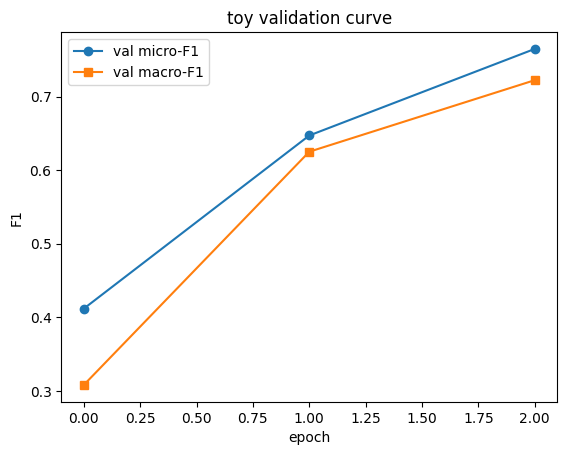

In [ ]:
print(f"{'epoch':>5} {'train_loss':>10} {'val_micro_f1':>12} {'val_macro_f1':>12} {'seconds':>8}")
for h in result["history"]:
    print(f"{h['epoch']:>5} {h['train_loss']:>10.4f} {h['val_micro_f1']:>12.4f} "
          f"{h['val_macro_f1']:>12.4f} {h['seconds']:>8.1f}")
print(f"\nbest epoch {result['best_epoch']}: micro {result['best_val_micro_f1']:.4f} / "
      f"macro {result['best_val_macro_f1']:.4f}  (stopped: {result['stopped']}, "
      f"{result['total_seconds']:.0f}s, {result['n_truncated_markers']} truncated markers)")

try:
    import matplotlib.pyplot as plt
    xs = [h["epoch"] for h in result["history"]]
    plt.plot(xs, [h["val_micro_f1"] for h in result["history"]], marker="o", label="val micro-F1")
    plt.plot(xs, [h["val_macro_f1"] for h in result["history"]], marker="s", label="val macro-F1")
    plt.xlabel("epoch"); plt.ylabel("F1"); plt.legend(); plt.title("toy validation curve")
    plt.show()
except ImportError:
    print("\n(matplotlib not installed — the text table above is the curve)")

Where the model errs: `best_confusions` lists the most frequent
gold → predicted mix-ups at the best epoch. On real data this is where the
paper's affiliation/location confusion clusters (`located_in`/`subsidiary`,
`president_of`/`lives_in`) show up; on the toy data it is mostly the
templated look-alikes.

In [ ]:
print("top confusions (gold → pred × count):")
for gold_label, pred_label, n in result["best_confusions"][:8]:
    print(f"  {gold_label} → {pred_label} × {n}")

top confusions (gold → pred × count):
  Personal.birth_place → Affiliation.member_of × 4


## 8. Constraint decoding

Relation types have signatures: `president_of` goes PERS→ORG/GPE, never
GPE→DATE. A softmax classifier doesn't know that — but we do, from two
sources unioned into one table: the task's published domain/range **spec**
(the cartesian product per relation, `re_constraints.SPEC`) plus every
`(subject_type, object_type)` pair **observed** with that label in training.
Observation *extends, never narrows*: gold annotations occasionally violate
the spec, and the data is what you're scored against. Pairs involving `UNK`
are fully permissive — unknown types shouldn't produce confident
constraints.

In [ ]:
from kgeval import re_constraints

table = re_constraints.ConstraintTable(
    re_constraints.observed_pairs(train_records, [type_of[r["triple_id"]] for r in train_records]))
print(f"spec rows: {len(re_constraints.SPEC)}; toy labels with a spec row: "
      f"{sum(1 for l in label_vocab if l in re_constraints.SPEC)}/{len(label_vocab)}")

mask = table.penalty_mask(label_vocab, "PERS", "GPE")  # True = INadmissible
print("\n(PERS, GPE) pair — admissibility per label:")
for label, bad in zip(label_vocab, mask):
    print(f"  {'INadmissible' if bad else 'admissible  '}  {label}")

spec rows: 39; toy labels with a spec row: 6/7

(PERS, GPE) pair — admissibility per label:
  INadmissible  Affiliation.member_of
  INadmissible  GPE.capital_of
  INadmissible  Location.located_in
  admissible    Personal.birth_place
  INadmissible  Personal.has_occupation
  INadmissible  Productivity.founder_of
  INadmissible  no_relation


The decode rule is a **soft penalty**, never a hard mask: inadmissible
logits (the raw pre-softmax scores the classifier emits) get a fixed constant
subtracted, so a confident model can still override a
wrong table entry — gold violates the spec sometimes, and a hard mask makes
every table error unrecoverable. `predict` applies the penalty first, then
the `-inf` mask on `no_relation`. How big should the penalty be? Sweep it on
dev, never on test. Below on the toy val set — mechanics only again; the
paper's real sweep is in §10.

In [ ]:
from kgeval import re_scoring

val_batches = re_train.make_batches(val_examples, tokenizer, label_index, cfg.batch_size, cfg.max_len)
val_gold = [(ex.triple_id, ex.label) for ex in val_examples]

print(f"{'penalty':>7} {'micro-F1':>9} {'macro-F1':>9}")
for p in [0.0, 1.0, 2.0, 3.0, 4.0]:
    preds = re_train.predict(model, val_batches, label_vocab, DEVICE,
                             masked_label=neg, constraints=table, penalty=p)
    sc = re_scoring.score(val_gold, preds, positives_only=True)
    print(f"{p:>7.1f} {sc.micro_f1:>9.4f} {sc.macro_f1:>9.4f}")
print("\n(toy numbers — the paper's dev sweep selected 3.0, maximizing macro-F1)")

penalty  micro-F1  macro-F1
    0.0    0.7647    0.7222


    1.0    1.0000    1.0000
    2.0    1.0000    1.0000
    3.0    1.0000    1.0000


    4.0    1.0000    1.0000

(toy numbers — the paper's dev sweep selected 3.0, maximizing macro-F1)


## 9. The fold ensemble (optional but included)

One held-out split is one noisy measurement. **Grouped k-fold** splits the
records into k sentence-disjoint parts and trains k models, each holding out
a different part — so every record ends up predicted by the one model that
never saw it (**out-of-fold**, OOF), and the k models ensemble for free. The
paper used k=5 with seed 13+fold; the quick path uses k=3. Combination is
**logit averaging**: average the raw pre-softmax scores, then apply penalty
and mask *after* averaging — once, to the consensus. `predict` returns
labels, though; ensembling needs the logits *before* the argmax, hence this
helper:

In [ ]:
def collect_logits(model, batches):
    """Per-example raw logits, aligned with triple_ids and type pairs."""
    model.eval()
    logits_all, tids, pairs = [], [], []
    with torch.no_grad():
        for b in batches:
            lg = model(b.enc["input_ids"].to(DEVICE), b.enc["attention_mask"].to(DEVICE),
                       b.subj_pos.to(DEVICE), b.obj_pos.to(DEVICE))
            logits_all.append(lg.cpu())
            tids.extend(b.triple_ids)
            pairs.extend(b.type_pairs)
    return torch.cat(logits_all), tids, pairs

In [ ]:
N_FOLDS = 5 if FULL_REPLICATION else 3  # the paper used 5
folds = splits.grouped_kfold(records, k=N_FOLDS, seed=SEED)

oof_logits = {}  # triple_id -> (logit row, (subj_type, obj_type))
for fi, (f_train, f_val) in enumerate(folds):
    f_tr_ex, _ = re_train.build_examples(f_train, [type_of[r["triple_id"]] for r in f_train])
    f_va_ex, _ = re_train.build_examples(f_val, [type_of[r["triple_id"]] for r in f_val])
    f_cfg = re_train.RETrainConfig(
        model_name=MODEL_NAME,
        seed=SEED + fi,  # the paper's 13+fold
        **({} if FULL_REPLICATION else {"max_len": 128, "max_epochs": 3, "patience": 2}),
    )
    f_model, _, f_res = re_train.run_re_training(
        f_tr_ex, f_va_ex, label_vocab, f_cfg, f"runs/fold{fi}", tokenizer=tokenizer)
    f_batches = re_train.make_batches(f_va_ex, tokenizer, label_index, f_cfg.batch_size, f_cfg.max_len)
    lg, tids, pairs = collect_logits(f_model, f_batches)
    for tid, row, pair in zip(tids, lg, pairs):
        oof_logits[tid] = (row, pair)
    print(f"fold {fi}: {len(f_tr_ex)} train / {len(f_va_ex)} val — "
          f"best val micro-F1 {f_res['best_val_micro_f1']:.4f}")
print(f"\npooled OOF: {len(oof_logits)} records, each predicted by a model that never saw it")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[data] 3 train / 2 val batches, 0 truncated markers, neg label 'no_relation'


[epoch 0] loss 2.1384 val micro-F1 0.5122 macro-F1 0.3345 0s


[epoch 1] loss 1.8540 val micro-F1 0.6829 macro-F1 0.6572 0s


...

[data] 3 train / 2 val batches, 0 truncated markers, neg label 'no_relation'


[epoch 0] loss 2.1334 val micro-F1 0.2683 macro-F1 0.1407 0s


[epoch 1] loss 1.8012 val micro-F1 0.3171 macro-F1 0.2224 0s


[epoch 2] loss 1.5917 val micro-F1 0.8293 macro-F1 0.7647 0s


fold 2: 95 train / 47 val — best val micro-F1 0.8293

pooled OOF: 142 records, each predicted by a model that never saw it


Now decode the pooled OOF logits: penalty and `no_relation` mask applied
*after* pooling — the same order as test-time decoding, where the k models'
logits are first averaged per test record (§10's recipe shows that step).
The finding to look for on real data (paper §RE results): constraints and
ensembling fix the *same* errors — the penalty was worth **+1.26 micro-F1**
on a single model but only **+0.08** on the 5-fold ensemble, its residual
value concentrated in macro-F1 (rare relations). On the toy data, expect the
opposite visual: the lift is enormous, because with 7 templated labels the
type pair nearly *determines* the label (§8's demo showed 1 of 7 labels
admissible for (PERS,GPE)) — real signatures only constrain, toy signatures
answer. Read it as the mechanism made visible, not as evidence.

In [ ]:
gold_all = [(r["triple_id"], r["relation"]) for r in records]
rows = torch.stack([oof_logits[tid][0] for tid, _ in gold_all])
pair_list = [oof_logits[tid][1] for tid, _ in gold_all]
neg_id = label_vocab.index(neg)

print(f"{'penalty':>7} {'micro-F1':>9} {'macro-F1':>9}   (pooled OOF, n={len(gold_all)})")
for p in [0.0, 1.0, 2.0, 3.0, 4.0]:
    adjusted = rows.clone()
    if p:
        inadmissible = torch.tensor([table.penalty_mask(label_vocab, s, o) for s, o in pair_list])
        adjusted = adjusted - p * inadmissible.float()
    adjusted[:, neg_id] = float("-inf")
    oof_preds = {tid: label_vocab[i] for (tid, _), i in zip(gold_all, adjusted.argmax(dim=-1).tolist())}
    sc = re_scoring.score(gold_all, oof_preds, positives_only=True)
    print(f"{p:>7.1f} {sc.micro_f1:>9.4f} {sc.macro_f1:>9.4f}")

penalty  micro-F1  macro-F1   (pooled OOF, n=142)
    0.0    0.8689    0.8538
    1.0    0.9590    0.9590
    2.0    0.9590    0.9590
    3.0    0.9590    0.9590
    4.0    0.9590    0.9590


## 10. Full replication — the paper's real numbers

Everything above ran on 142 toy records; here is what the same code produces
on real WojoodRelations data with the paper's config (the `RETrainConfig`
defaults: lr 2e-5, wd 0.01, batch 32, max_len 256, dropout 0.1, ≤10 epochs
patience 2, clip 1.0, seed 13, 13+fold for the ensemble):

- single model, dev (15,207 train / 2,174 dev, grouped): 0.9344 micro /
  0.649 macro; **+ penalty 3.0 → 0.9470 / 0.705**
- 5-fold ensemble, pooled OOF over all 17,381 records: 0.9592 / 0.638;
  **+ penalty 3.0 → 0.95995 / 0.648**
- official blind test (4,386 pairs): **0.9519** single, **0.9571** ensemble

The pooled-OOF penalty sweep is monotone and flat near the top — micro
0.95920 / 0.95952 / 0.95984 / 0.95995 / 0.96006 for penalties 0–4 — and 3.0
maximizes macro-F1, so 3.0 it is. The OOF estimate predicted the blind score
within 0.3 points. The ensemble changed 97/4,386 predictions (2.2%) vs. the
single model, concentrated in the `located_in`/`subsidiary` and
`president_of`/`lives_in` confusion clusters. Cost on one T4: ~68 min for
the 5-fold ensemble (a single model is roughly one fold of that). The cell
below is the
complete recipe, commented out — uncomment it with the §3 files in place.

In [ ]:
# ===== FULL REPLICATION — uncomment with real_data/ in place (§3) =====
# On a Colab T4: ~68 min for the 5-fold ensemble; a single model is roughly
# one fold of that (~15 min).
#
# real_records = re_data.load_jsonl(REAL_TRAIN_JSONL)
# real_gsid = re_typing.read_csv_nested(REAL_WOJOOD_CSV)
# real_lexicon = re_typing.build_lexicon(real_gsid)
# real_types, join_stats = re_typing.assign_types(real_records, real_gsid, real_lexicon)
# print(join_stats)  # blind-test coverage: 99.4% joined; 97.8% subj / 97.9% obj typed
# real_vocab = sorted(re_data.label_counts(real_records))   # 41 labels
# real_neg = re_data.detect_no_relation(set(real_vocab))
# real_index = {l: i for i, l in enumerate(real_vocab)}
# type_of = {r["triple_id"]: t for r, t in zip(real_records, real_types)}
#
# # --- single model (v1 submission: blind test 0.9519) ---
# tr, va, _ = splits.grouped_split(real_records, val_frac=0.125, seed=SEED)
# tr_ex, _ = re_train.build_examples(tr, [type_of[r["triple_id"]] for r in tr])
# va_ex, _ = re_train.build_examples(va, [type_of[r["triple_id"]] for r in va])
# cfg = re_train.RETrainConfig(model_name=MODEL_NAME)  # defaults ARE the paper config
# model, tokenizer, res = re_train.run_re_training(tr_ex, va_ex, real_vocab, cfg, "runs/full")
# table = re_constraints.ConstraintTable(
#     re_constraints.observed_pairs(tr, [type_of[r["triple_id"]] for r in tr]))
# va_batches = re_train.make_batches(va_ex, tokenizer, real_index, cfg.batch_size, cfg.max_len)
# preds = re_train.predict(model, va_batches, real_vocab, DEVICE,
#                          masked_label=real_neg, constraints=table, penalty=3.0)
# print(re_scoring.score([(e.triple_id, e.label) for e in va_ex], preds).pretty())
#
# # --- 5-fold ensemble (v2 submission: blind test 0.9571) ---
# # Exactly §9's loop with k=5 and paper configs on real_records: train one
# # model per fold (seed 13+fold), collect_logits on each held-out fold, and
# # decode the pooled OOF logits with penalty 3.0 + the no_relation mask —
# # expect pooled-OOF ≈ 0.95995 micro / 0.648 macro. For the blind test,
# # average the five models' logits per test record first, then constrain.

## 11. Where to go next

- The paper: *"Rabt at KnowledgeGraphEval 2026"* (Team Rabt, ArabicNLP 2026)
  — System Overview §RE, Results, and the appendix penalty-sweep table.
- `docs/learning-corner/paper-companion.md` §8–§10 in the repo: the long-form
  teaching version of what §4–§9 here showed running.
- Notebook 1 (`01-adaptner-nested-ner.ipynb`): how the entities themselves
  are found — the nodes these edges connect.

Roads the paper deliberately did not take, with the one-line reason:

- **LLM-only prediction** — the task's own GPT-4o RAG baseline (85.78) trails
  its supervised baseline (88.61) by ~3 points.
- **Negative downsampling** — dropping `no_relation` pairs from training
  costs ~10 F1 in comparable settings.
- **Hard constraint masking** — gold annotations occasionally violate the
  type spec, so constraints must stay soft.